## Gene Imputation (2D)

The example data used for this tutorial can be downloaded from:

https://drive.google.com/file/d/16yGWgy4CUiEZG6yOz9XJzWCOdthx_Qy5/view?usp=sharing

In [1]:
!git clone https://github.com/lanshui98/UniST.git
%cd UniST

Cloning into 'UniST'...
remote: Enumerating objects: 324, done.
remote: Counting objects: 100% (324/324), done.
remote: Compressing objects: 100% (288/288), done.
remote: Total 324 (delta 114), reused 182 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (324/324), 7.41 MiB | 16.28 MiB/s, done.
Resolving deltas: 100% (114/114), done.
/content/UniST


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.8/199.8 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.

Note the the spatial information should be at adata.obsm['spatial'];

Put the adata under external/SUICA_pro/data/.

In [3]:
%cd external/SUICA_pro

/content/UniST/external/SUICA_pro


In [8]:
! pip install scanpy

### Read the Data

In [9]:
import scanpy as sc

In [15]:
adata_path = 'data/slice_440.h5ad'
a = sc.read(adata_path)

In [16]:
a

AnnData object with n_obs × n_vars = 8382 × 17649
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    obsm: 'X_pca', 'bbox', 'spatial'

##### Visulize gene expression

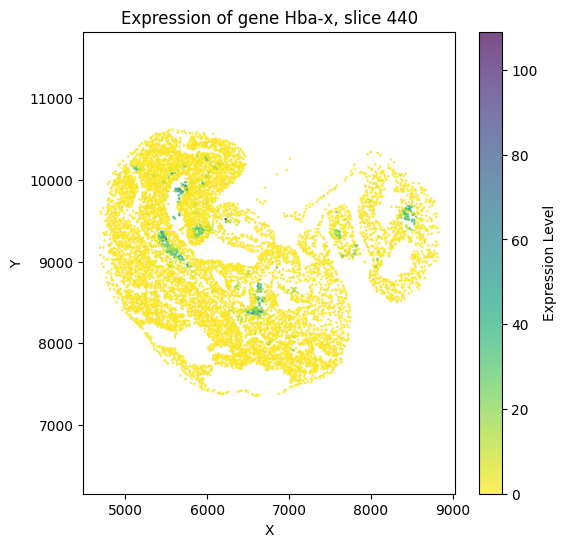

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Extract coordinates and gene expression values
coordinates = a.obsm['spatial'][:, 0:2]

# Handle sparse matrix for gene expression values
if hasattr(a.X, "tocsc"):  # check if sparse
    values = a.X[:, 8293].toarray().flatten()
else:
    values = a.X[:, 8293]

n_points = coordinates.shape[0]

# Visualization
plt.figure(figsize=(6, 6))
plt.scatter(coordinates[:, 0], coordinates[:, 1], c=values, cmap='viridis_r', s=1, alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Expression of gene Hba-x, slice 440")
plt.axis('equal')
plt.colorbar(label='Expression Level')
#plt.savefig('slice440_Hba-x.png', format='png', dpi=300)
plt.show()

### Step1: Train GAE

In [27]:
!python train.py --mode embedder --conf ./configs/ST/embedder_gae.yaml

./configs/ST/embedder_gae.yaml
Current Configs:
{
│   'case': '2d',
│   'dataset': {
│   │   'type': 'GraphST2D',
│   │   'data_file': 'data/slice_440.h5ad',
│   │   'val_proportion': 0.2,
│   │   'keep_ratio': True,
│   │   'n_neighbors': 4,
│   │   'require_coordnorm': True
│   },
│   'pipeline': {
│   │   'embedder': {
│   │   │   'model': 'GAE',
│   │   │   'dim_hidden': [
│   │   │   │   2048,
│   │   │   │   512,
│   │   │   │   128
│   │   │   ],
│   │   │   'dim_latent': 64
│   │   },
│   │   'optimization': {
│   │   │   'seed': 8848,
│   │   │   'epochs': 1000,
│   │   │   'lr': 1e-05,
│   │   │   'val_freq': 50,
│   │   │   'logs': 'logs/GAE-2D/2d',
│   │   │   'batch_size': 512
│   │   },
│   │   'predict_mode': 'all',
│   │   'embedded_data': 'embedded-all.h5ad'
│   }
}
[CONF] conf     = /content/UniST/external/SUICA_pro/configs/ST/embedder_gae.yaml
[CONF] datafile = /content/UniST/external/SUICA_pro/data/slice_440.h5ad
[CONF] logs_dir = /content/UniST/external/SUICA_pro/l

#### Visulize latent space

In [ ]:
emb = sc.read('/content/UniST/external/SUICA_pro/logs/GAE-2D/2d/lightning_logs/version_0/embedded-all.h5ad')

In [11]:
emb

AnnData object with n_obs × n_vars = 8382 × 17649
    obsm: 'embeddings', 'spatial'

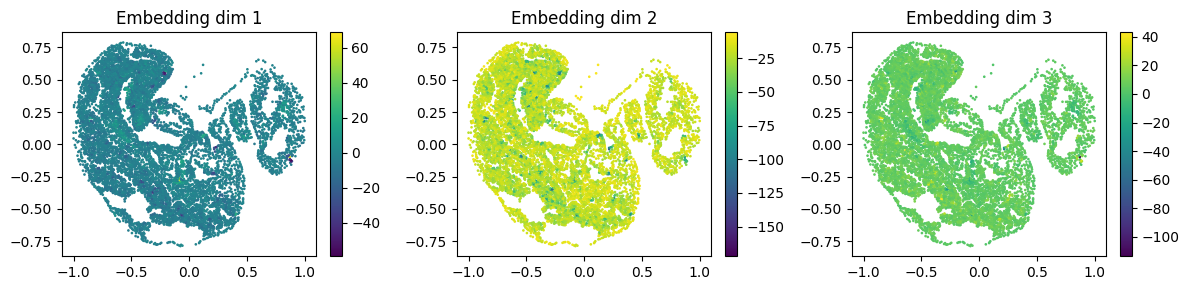

In [43]:
import matplotlib.pyplot as plt

embeddings = emb.obsm["embeddings"]
spatial = emb.obsm["spatial"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for idx, dim in enumerate(range(3)): # first three
    sc = axes[idx].scatter(
        spatial[:, 0],
        spatial[:, 1],
        c=embeddings[:, dim],
        cmap="viridis",
        s=0.8
    )
    axes[idx].set_title(f"Embedding dim {dim+1}")
    plt.colorbar(sc, ax=axes[idx], fraction=0.046)

plt.tight_layout()
plt.show()

### Step2: Train INR + fine-tune GAE

In [20]:
!python train.py --mode inr --conf ./configs/ST/inr_embd.yaml

./configs/ST/inr_embd.yaml
Current Configs:
{
│   'case': '2d',
│   'dataset': {
│   │   'type': 'ST2D',
│   │   'data_file': 'logs/GAE-2D/2d/lightning_logs/version_0/embedded-all.h5ad',
│   │   'val_proportion': 0.2,
│   │   'keep_ratio': True,
│   │   'require_coordnorm': False
│   },
│   'pipeline': {
│   │   'target': 'embeddings',
│   │   'inr': {
│   │   │   'model': 'FFN',
│   │   │   'num_hidden_layers': 3,
│   │   │   'num_hidden_features': 2048,
│   │   │   'phase': 1000,
│   │   │   'decoder': {
│   │   │   │   'ckpt': 'logs/GAE-2D/2d/lightning_logs/version_0/checkpoints/last.ckpt',
│   │   │   │   'recon_loss': True,
│   │   │   │   'finetune': True
│   │   │   }
│   │   },
│   │   'optimization': {
│   │   │   'seed': 8848,
│   │   │   'epochs': 2000,
│   │   │   'lr': 0.0001,
│   │   │   'val_freq': 200,
│   │   │   'logs': 'logs/GAE+FFN-2D/2d',
│   │   │   'batch_size': 5000
│   │   },
│   │   'predict_mode': 'val',
│   │   'reconstructed_data': 'reconstructed-val.h5ad'


### Step3: Prediction/Imputation

#### Prepare normalized custom coords first

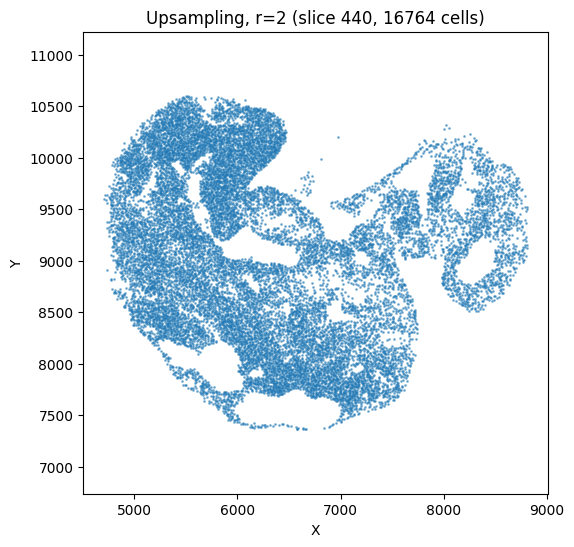

In [24]:
### The upsampled point cloud

import numpy as np
import matplotlib.pyplot as plt

file_path = "data/slice440_r2.xyz"

points = []
with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            x, y = float(parts[0]), float(parts[1])
            points.append((x, y))

points = np.array(points)
n_points = points.shape[0]

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=1, alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Upsampling, r=2 (slice 440, {n_points} cells)")
plt.axis('equal')
#plt.savefig('slice440_r2.png', format='png', dpi=300)
plt.show()

In [26]:
!python prepare_custom_coords.py --mode 2d --reference data/slice_440.h5ad --coords data/slice440_r2.xyz --output data/preprocessed_data/custom_coords_2d_norm.npy

Reading reference data: data/slice_440.h5ad
Reading coordinate file: data/slice440_r2.xyz
Input coordinate shape: (16764, 3)

Normalized coordinate ranges:
  X: [-0.9912, 0.9935]
  Y: [-0.7844, 0.7798]
Shape: (16764, 2)

✅ Saved 16764 2D coordinates to data/preprocessed_data/custom_coords_2d_norm.npy


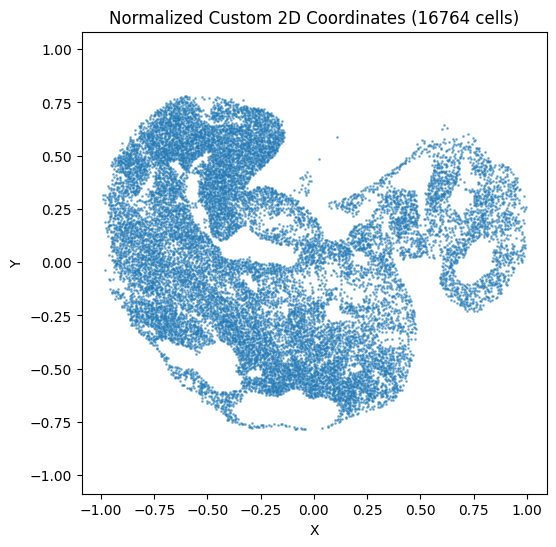

In [28]:
file_path = "data/preprocessed_data/custom_coords_2d_norm.npy"

# Load points from the .npy file
points = np.load(file_path)
n_points = points.shape[0]

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=1, alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Normalized Custom 2D Coordinates ({n_points} cells)")
plt.axis('equal')
plt.show()

In [30]:
# Run prediction
!python predict.py --mode inr --conf ./configs/ST/inr_pred.yaml

./configs/ST/inr_pred.yaml
Current Configs:
{
│   'case': '2d',
│   'dataset': {
│   │   'type': 'ST2D',
│   │   'data_file': 'logs/GAE-2D/2d/lightning_logs/version_0/embedded-all.h5ad',
│   │   'val_proportion': 0.2,
│   │   'keep_ratio': True,
│   │   'require_coordnorm': False
│   },
│   'pipeline': {
│   │   'target': 'embeddings',
│   │   'prediction': {
│   │   │   'ckpt': 'logs/GAE+FFN-2D/2d/lightning_logs/version_0/checkpoints/last.ckpt'
│   │   },
│   │   'inr': {
│   │   │   'model': 'FFN',
│   │   │   'num_hidden_layers': 3,
│   │   │   'num_hidden_features': 2048,
│   │   │   'phase': 1000,
│   │   │   'decoder': {
│   │   │   │   'ckpt': 'logs/GAE-2D/2d/lightning_logs/version_0/checkpoints/last.ckpt',
│   │   │   │   'recon_loss': True,
│   │   │   │   'finetune': True
│   │   │   }
│   │   },
│   │   'optimization': {
│   │   │   'seed': 8848,
│   │   │   'epochs': 2000,
│   │   │   'lr': 0.0001,
│   │   │   'val_freq': 200,
│   │   │   'logs': 'logs/GAE+FFN-2D/2d',
│   │

In [31]:
# Map reconstructed coords back to original space
!python map_coords_back.py --reconstructed logs/GAE+FFN-2D/2d/lightning_logs/version_1/reconstructed-custom_2d.h5ad --reference data/slice_440.h5ad --output logs/GAE+FFN-2D/2d/lightning_logs/version_1/reconstructed-original.h5ad --mode 2d


Reading prediction results: logs/GAE+FFN-2D/2d/lightning_logs/version_1/reconstructed-custom_2d.h5ad
Normalized coordinate shape: (16764, 2)
Normalized coordinate ranges:
  min: [-0.9911625 -0.784444 ]
  max: [0.99346364 0.77975   ]

Reading reference data: data/slice_440.h5ad

Denormalizing coordinates...
Parameters: keep_ratio=True
Reference data coordinate ranges:
  X: [4691.54, 8823.75], range=4132.22
  Y: [7357.52, 10613.24], range=3255.72
Scaling factors (keep_ratio=True): scale_x=1.0000, scale_y=0.7879

Denormalized coordinate ranges:
  min: [4709.79491889 7364.63086083]
  max: [ 8810.24711702 10596.42476476]

Saving results to: logs/GAE+FFN-2D/2d/lightning_logs/version_1/reconstructed-original.h5ad
✓ Done!

Output file contains:
  - obsm['spatial']: Original coordinates (mapped results)
  - obsm['spatial_normalized']: Normalized coordinates (backup)
  - Other prediction results remain unchanged


In [34]:
res = sc.read('logs/GAE+FFN-2D/2d/lightning_logs/version_1/reconstructed-original.h5ad')

In [35]:
res

AnnData object with n_obs × n_vars = 16764 × 1
    obsm: 'fitted_embd', 'reconstructed_raw', 'spatial', 'spatial_normalized'

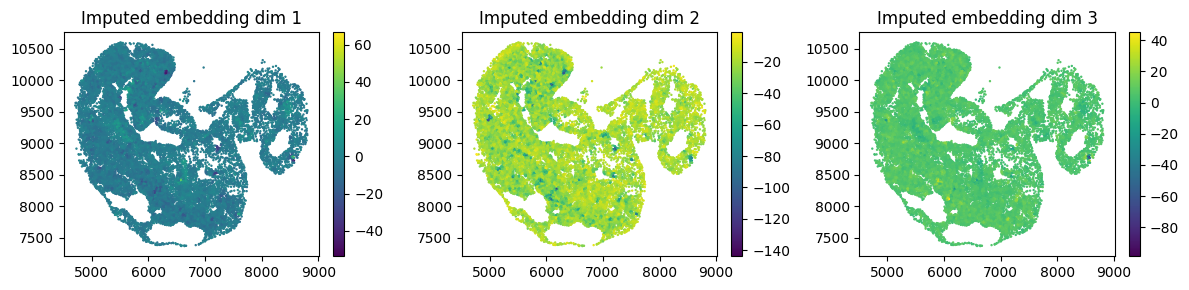

In [45]:
### Visualize the imputed embeddings

embeddings = res.obsm["fitted_embd"]
spatial = res.obsm["spatial"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for idx, dim in enumerate(range(3)): # first three
    sc = axes[idx].scatter(
        spatial[:, 0],
        spatial[:, 1],
        c=embeddings[:, dim].toarray().flatten(),
        cmap="viridis",
        s=0.5
    )
    axes[idx].set_title(f"Imputed embedding dim {dim+1}")
    plt.colorbar(sc, ax=axes[idx], fraction=0.046)

plt.tight_layout()
plt.show()

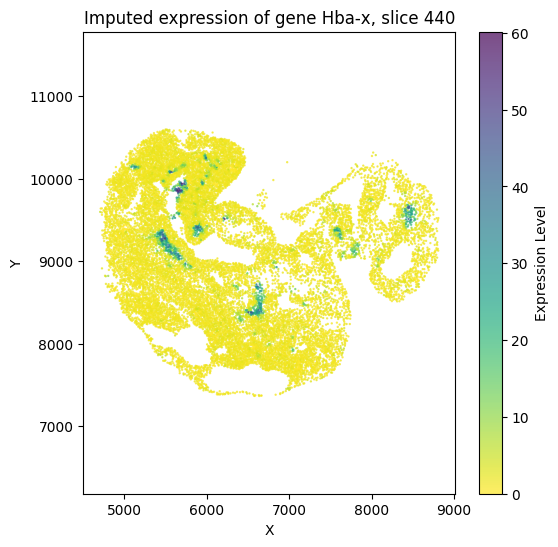

In [46]:
### Visualize the imputed gene expression

coordinates = res.obsm['spatial'][:, 0:2]
values = res.obsm['reconstructed_raw'][:, 8293]
n_points = coordinates.shape[0]

# Visualization
plt.figure(figsize=(6, 6))
plt.scatter(coordinates[:, 0], coordinates[:, 1], c=values, cmap='viridis_r', s=0.5, alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Imputed expression of gene Hba-x, slice 440")
plt.axis('equal')
plt.colorbar(label='Expression Level')
#plt.savefig('slice440_Hba-x.png', format='png', dpi=300)
plt.show()